In [366]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [367]:
import matplotlib.pyplot as plt
import seaborn as sns

Read Raw Data


In [368]:
df_prod = pd.read_csv('data/dataset/well_and_production.csv')
df_interv = pd.read_excel('data/dataset/interventions_report.xlsx', skiprows=2)

WELL & PRODUCTION


In [369]:
display(df_prod.head())

,well_id,well_name,field,well_type,status,spud_date,latitude,longitude,measured_depth_md,true_vertical_depth_tvd,tvdss,depth_unit,operator,production_date,oil_volume_bbl,gas_volume_mcf,water_volume_bbl,days_online,choke_size_inches,tubing_pressure_psi,casing_pressure_psi
0,TM-007,Tanjung Merah Well 7,Tanjung Merah,Vertical,Active,2019-06-01,-1.46549,116.20023,3030.0,3004.6,2983.2,meters,PT Muara Dua Energy,2021-11-01,0.0,0.0,0.0,0,0.500,NaN,NaN
1,SB-006,Sungai Biru Well 6,Sungai Biru,Directional,Active,2018-03-01,-1.80725,116.53048,2812.0,3012.0,2073.6,meters,PT Muara Dua Energy,2025-12-01,2557.0,1787.9,3210.8,15,0.375,438.0,378.0
2,SB-006,Sungai Biru Well 6,Sungai Biru,Directional,Active,2018-03-01,-1.80725,116.53048,2812.0,3012.0,2073.6,meters,PT Muara Dua Energy,2024-05-01,4703.6,2907.9,3356.9,30,0.250,368.0,879.0
3,TM-007,Tanjung Merah Well 7,Tanjung Merah,Vertical,Active,2019-06-01,-1.46549,116.20023,3030.0,3004.6,2983.2,meters,PT Muara Dua Energy,2020-02-01,17543.0,11551.5,3785.2,30,0.500,520.0,428.0
4,SB-016,Sungai Biru Well 16,Sungai Biru,Horizontal,Active,2021-05-01,-1.82100,116.50588,2800.0,1825.3,1805.2,meters,PT Muara Dua Energy,2024-12-01,18024.1,17025.5,11335.0,30,0.250,539.0,379.0


In [370]:
df_prod.info()

<class 'pandas.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   well_id                  1510 non-null   str    
 1   well_name                1510 non-null   str    
 2   field                    1510 non-null   str    
 3   well_type                1510 non-null   str    
 4   status                   1510 non-null   str    
 5   spud_date                1455 non-null   str    
 6   latitude                 1510 non-null   float64
 7   longitude                1510 non-null   float64
 8   measured_depth_md        1510 non-null   float64
 9   true_vertical_depth_tvd  1510 non-null   float64
 10  tvdss                    1510 non-null   float64
 11  depth_unit               1510 non-null   str    
 12  operator                 1510 non-null   str    
 13  production_date          1510 non-null   str    
 14  oil_volume_bbl           1498 non-n

In [371]:
print(df_prod.isnull().sum())

well_id                     0
well_name                   0
field                       0
well_type                   0
status                      0
spud_date                  55
latitude                    0
longitude                   0
measured_depth_md           0
true_vertical_depth_tvd     0
tvdss                       0
depth_unit                  0
operator                    0
production_date             0
oil_volume_bbl             12
gas_volume_mcf             13
water_volume_bbl            5
days_online                 0
choke_size_inches           0
tubing_pressure_psi        88
casing_pressure_psi        88
dtype: int64


Analyze data & Data Cleaning


Well & Drilling Terms


In [372]:
print(df_prod['well_id'].value_counts())

well_id
BH-001    93
SB-006    92
TM-024    92
SB-012    91
TM-018    81
SB-023    80
TM-007    77
TM-019    73
BH-017    72
BH-011    71
TM-021    68
SB-008    61
BH-010    61
BH-014    58
SB-016    55
BH-015    55
BH-020    52
SB-025    44
SB-009    44
TM-003    41
TM-004    37
TM-002    32
SB-013    29
BH-005    26
SB-022    25
Name: count, dtype: int64


In [373]:
print(df_prod['field'].value_counts())

field
Tanjung Merah     501
Bukit Harapan     488
Sungai Biru       460
Tanjung Merahh     61
Name: count, dtype: int64


In [374]:
#mengubah variabel yang typo
df_prod['field'] = df_prod['field'].replace('Tanjung Merahh', 'Tanjung Merah')
print(df_prod['field'].value_counts())

field
Tanjung Merah    562
Bukit Harapan    488
Sungai Biru      460
Name: count, dtype: int64


In [375]:
print(f"Jumlah Lapangan: {df_prod['field'].nunique()}")
print(f"Jumlah Sumur: {df_prod['well_id'].nunique()}")

Jumlah Lapangan: 3
Jumlah Sumur: 25


In [376]:
print(df_prod['well_name'].value_counts())

well_name
Bukit Harapan Well 1       93
Sungai Biru Well 6         92
Tanjung Merah Well 24      92
Sungai Biru  Well 12       91
Tanjung Merah Well 18      81
Sungai Biru Well 23        80
Tanjung Merah Well 7       77
Tanjung Merah Well 19      73
Bukit Harapan Well 17      72
Bukit Harapan Well 11      71
Tanjung Merah Well 21      68
Sungai Biru Well 8         61
Bukit Harapan Well 10      61
Bukit Harapan Well 14      58
Sungai Biru Well 16        55
Bukit Harapan Well 15      55
Bukit Harapan Well 20      52
Sungai Biru Well 25        44
Sungai Biru Well 9         44
  Tanjung Merah Well 3     41
Tanjung Merah Well 4       37
Tanjung Merah Well 2       32
Sungai Biru Well 13        29
Bukit Harapan Well 5       26
Sungai Biru Well 22        25
Name: count, dtype: int64


In [377]:
# Menghapus whitespace di awal dan akhir string
df_prod['well_name'] = df_prod['well_name'].str.strip()

In [378]:
print(df_prod['well_name'].value_counts())

well_name
Bukit Harapan Well 1     93
Sungai Biru Well 6       92
Tanjung Merah Well 24    92
Sungai Biru  Well 12     91
Tanjung Merah Well 18    81
Sungai Biru Well 23      80
Tanjung Merah Well 7     77
Tanjung Merah Well 19    73
Bukit Harapan Well 17    72
Bukit Harapan Well 11    71
Tanjung Merah Well 21    68
Sungai Biru Well 8       61
Bukit Harapan Well 10    61
Bukit Harapan Well 14    58
Sungai Biru Well 16      55
Bukit Harapan Well 15    55
Bukit Harapan Well 20    52
Sungai Biru Well 25      44
Sungai Biru Well 9       44
Tanjung Merah Well 3     41
Tanjung Merah Well 4     37
Tanjung Merah Well 2     32
Sungai Biru Well 13      29
Bukit Harapan Well 5     26
Sungai Biru Well 22      25
Name: count, dtype: int64


In [379]:
print(df_prod['well_type'].value_counts())

well_type
Vertical       551
Directional    505
Horizontal     454
Name: count, dtype: int64


In [380]:
print(df_prod['status'].value_counts())

status
Active     1253
Shut-In     185
active       72
Name: count, dtype: int64


In [381]:
# Menghapus spasi tambahan dan menyamakan format huruf
df_prod['status'] = df_prod['status'].str.strip().str.title()
print(df_prod['status'].value_counts())

status
Active     1325
Shut-In     185
Name: count, dtype: int64


In [382]:
print(df_prod['spud_date'].value_counts())

spud_date
2018-03-01    184
01/01/2018     93
01/04/2018     91
2019-01-01     81
2019-03-01     80
2019-06-01     77
2019-10-01     73
2019-11-01     72
2019-12-01     71
2020-03-01     68
2020-10-01     61
2020-11-01     61
2020-12-01     58
2021-05-01     55
2021-07-01     52
2022-02-01     44
01/02/2022     44
2022-07-01     41
01/10/2022     37
01/02/2023     32
2023-06-01     29
2023-09-01     26
2023-10-01     25
Name: count, dtype: int64


In [383]:
df_prod['spud_date_original'] = df_prod['spud_date'].astype(str).str.strip()

def fix_date_format(date_str):
    if pd.isna(date_str) or date_str.lower() in ['nan', 'none', '']:
        return None
    clean_str = str(date_str).replace('.', '/').strip()
    try:
        return pd.to_datetime(clean_str, dayfirst=True).strftime('%Y-%m-%d')
    except:
        return None
df_prod['spud_date_fixed_str'] = df_prod['spud_date'].apply(fix_date_format)
df_prod['spud_date'] = pd.to_datetime(df_prod['spud_date_fixed_str'], errors='coerce')
print(df_prod['spud_date'].value_counts())

spud_date
2018-01-03    184
2018-01-01     93
2018-04-01     91
2019-01-01     81
2019-01-03     80
2019-01-06     77
2019-01-10     73
2019-01-11     72
2019-01-12     71
2020-01-03     68
2020-01-10     61
2020-01-11     61
2020-01-12     58
2021-01-05     55
2021-01-07     52
2022-01-02     44
2022-02-01     44
2022-01-07     41
2022-10-01     37
2023-02-01     32
2023-01-06     29
2023-01-09     26
2023-01-10     25
Name: count, dtype: int64


Depth Measurements


In [384]:
print(df_prod['depth_unit'].value_counts())

depth_unit
meters    946
feet      564
Name: count, dtype: int64


In [385]:
# Konversi unit kedalaman (Meters ke Feet)

depth_cols = ['measured_depth_md', 'true_vertical_depth_tvd', 'tvdss']

def normalize_all_depths(row):
    conversion_factor = 3.28084
    if row['depth_unit'] == 'meters':
        for col in depth_cols:
            row[col] = row[col] * conversion_factor
        row['depth_unit'] = 'feet'
    return row

df_prod = df_prod.apply(normalize_all_depths, axis=1)

In [386]:
print(df_prod['depth_unit'].value_counts())

depth_unit
feet    1510
Name: count, dtype: int64


In [387]:
# Cek apakah ada kedalaman negatif
invalid_depths = df_prod[(df_prod['measured_depth_md'] <= 0) | (df_prod['true_vertical_depth_tvd'] <= 0)]
print(invalid_depths[['well_name', 'measured_depth_md', 'true_vertical_depth_tvd']])

Empty DataFrame
Columns: [well_name, measured_depth_md, true_vertical_depth_tvd]
Index: []


In [388]:
physical_error = df_prod[df_prod['true_vertical_depth_tvd'] > df_prod['measured_depth_md']]
if not physical_error.empty:
    print(f"Peringatan: Ditemukan {len(physical_error)} baris dengan TVD > MD (Data Error)!")

Peringatan: Ditemukan 92 baris dengan TVD > MD (Data Error)!


Production Metrics


In [389]:
# Cek apakah ada sumur yang choke-nya 0 tapi masih berproduksi
choke_error = df_prod[(df_prod['choke_size_inches'] == 0) & (df_prod['oil_volume_bbl'] > 0)]
print(f"Ditemukan {len(choke_error)} baris data aneh: Choke tertutup tapi ada produksi.")
if not choke_error.empty:
    display(choke_error[['well_name', 'choke_size_inches', 'oil_volume_bbl', 'status']])

Ditemukan 0 baris data aneh: Choke tertutup tapi ada produksi.


In [390]:
print(df_prod['operator'].value_counts())

operator
PT Muara Dua Energy    1510
Name: count, dtype: int64


In [391]:
df_prod['production_date'] = pd.to_datetime(df_prod['production_date'], errors='coerce')

In [392]:
print(df_prod['days_online'].value_counts())

days_online
30    935
28    217
25    132
0      88
15     69
20     69
Name: count, dtype: int64


Water Cut


In [393]:
total_liquid = df_prod['water_volume_bbl'] + df_prod['oil_volume_bbl']
df_prod['water_cut'] = df_prod['water_volume_bbl'] / total_liquid
df_prod['water_cut'] = df_prod['water_cut'].fillna(0)
df_prod['water_cut_pct'] = df_prod['water_cut'] * 100
print(df_prod[['well_name', 'oil_volume_bbl', 'water_volume_bbl', 'water_cut_pct']].head())

              well_name  oil_volume_bbl  water_volume_bbl  water_cut_pct
0  Tanjung Merah Well 7             0.0               0.0       0.000000
1    Sungai Biru Well 6          2557.0            3210.8      55.667672
2    Sungai Biru Well 6          4703.6            3356.9      41.646300
3  Tanjung Merah Well 7         17543.0            3785.2      17.747395
4   Sungai Biru Well 16         18024.1           11335.0      38.608132


GOR (Gas-Oil Ratio)


In [394]:
df_prod['gor'] = (df_prod['gas_volume_mcf'] * 1000) / df_prod['oil_volume_bbl'].replace(0, pd.NA)
df_prod['gor'] = df_prod['gor'].fillna(0).astype(float)
display(df_prod[['well_name', 'oil_volume_bbl', 'gas_volume_mcf', 'gor']].head())

,well_name,oil_volume_bbl,gas_volume_mcf,gor
0,Tanjung Merah Well 7,0.0,0.0,0.000000
1,Sungai Biru Well 6,2557.0,1787.9,699.217833
2,Sungai Biru Well 6,4703.6,2907.9,618.228591
3,Tanjung Merah Well 7,17543.0,11551.5,658.467765
4,Sungai Biru Well 16,18024.1,17025.5,944.596401


Production Decline/Penurunan Produksi


In [395]:
# hitung total produksi bulanan per lapangan (Field)
decline_analysis = df_prod.groupby(['field', 'production_date'])['oil_volume_bbl'].sum().reset_index()
print("Tren Produksi per Lapangan:")
display(decline_analysis.sort_values(['field', 'production_date'], ascending=[True, False]).head(10))

Tren Produksi per Lapangan:


,field,production_date,oil_volume_bbl
97,Bukit Harapan,2025-12-01,29050.6
96,Bukit Harapan,2025-11-01,27868.7
95,Bukit Harapan,2025-10-01,31810.9
94,Bukit Harapan,2025-09-01,33082.5
93,Bukit Harapan,2025-08-01,26847.4
92,Bukit Harapan,2025-07-01,27567.3
91,Bukit Harapan,2025-06-01,36209.7
90,Bukit Harapan,2025-05-01,35719.3
89,Bukit Harapan,2025-04-01,39361.1
88,Bukit Harapan,2025-03-01,41614.7


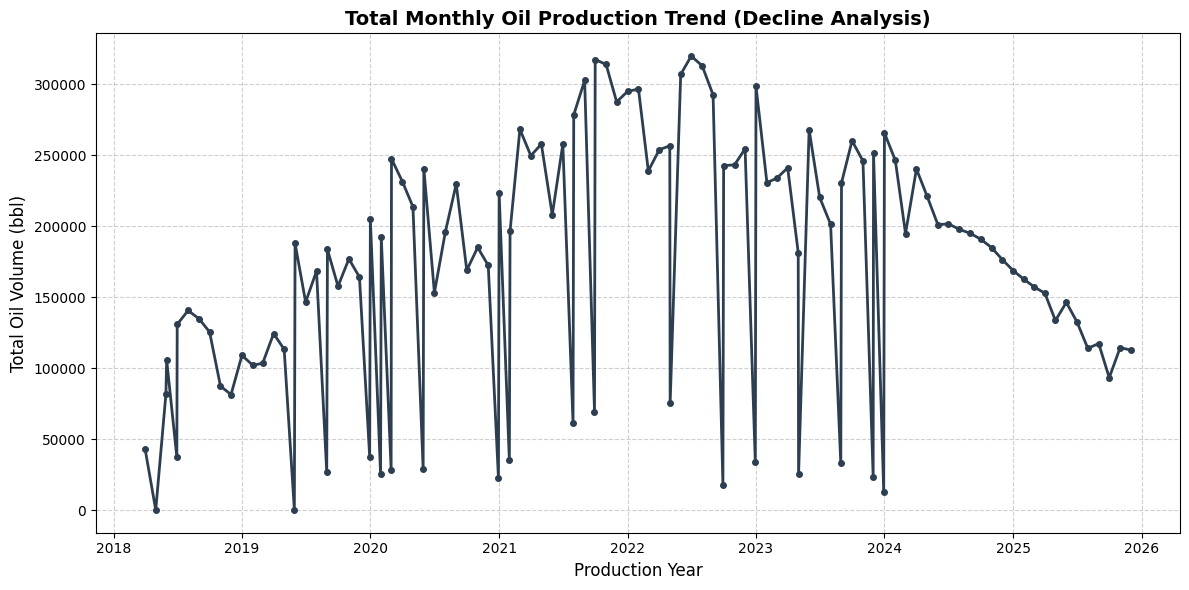

In [396]:
# hitung total produksi bulanan
df_trend = df_prod.groupby('production_date')['oil_volume_bbl'].sum().reset_index()
df_trend = df_trend.sort_values('production_date')
plt.figure(figsize=(12, 6))
plt.plot(df_trend['production_date'], df_trend['oil_volume_bbl'], 
         marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=4)
plt.title('Total Monthly Oil Production Trend (Decline Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Production Year', fontsize=12)
plt.ylabel('Total Oil Volume (bbl)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Negative production volumes


In [397]:
display(df_prod[df_prod['days_online'] > 0][['oil_volume_bbl', 'gas_volume_mcf', 'water_volume_bbl']].describe())

,oil_volume_bbl,gas_volume_mcf,water_volume_bbl
count,1410.000000,1411.000000,1417.000000
mean,13578.150922,16872.170730,4167.175653
std,11574.290702,15491.016388,2698.173402
min,-150.000000,647.100000,529.400000
25%,4534.225000,5034.850000,2379.100000
50%,10495.500000,11884.800000,3544.400000
75%,19202.825000,23547.550000,4987.600000
max,74068.200000,86901.600000,16270.700000


In [398]:
prod_cols = ['oil_volume_bbl', 'gas_volume_mcf', 'water_volume_bbl']
for col in prod_cols:
    neg_count = (df_prod[col] < 0).sum()
    print(f"Jumlah data negatif di {col}: {neg_count}")
df_prod[prod_cols] = df_prod[prod_cols].clip(lower=0)

Jumlah data negatif di oil_volume_bbl: 1
Jumlah data negatif di gas_volume_mcf: 0
Jumlah data negatif di water_volume_bbl: 0


In [399]:
display(df_prod[df_prod['days_online'] > 0][['oil_volume_bbl', 'gas_volume_mcf', 'water_volume_bbl']].describe())

,oil_volume_bbl,gas_volume_mcf,water_volume_bbl
count,1410.000000,1411.000000,1417.000000
mean,13578.257305,16872.170730,4167.175653
std,11574.165121,15491.016388,2698.173402
min,0.000000,647.100000,529.400000
25%,4534.225000,5034.850000,2379.100000
50%,10495.500000,11884.800000,3544.400000
75%,19202.825000,23547.550000,4987.600000
max,74068.200000,86901.600000,16270.700000


In [400]:
logic_error = df_prod[(df_prod['days_online'] == 0) & (df_prod['oil_volume_bbl'] > 0)]
print(f"Ditemukan {len(logic_error)} sumur offline tapi menghasilkan minyak.")

Ditemukan 0 sumur offline tapi menghasilkan minyak.


Pressures & Offline Wells


In [401]:
pressure_null_tubing = df_prod[(df_prod['days_online'] > 0) & (df_prod['tubing_pressure_psi'].isnull())]
pressure_null_casing = df_prod[(df_prod['days_online'] > 0) & (df_prod['casing_pressure_psi'].isnull())]
print(f"Ditemukan {len(pressure_null_tubing)} sumur aktif tapi data tekanan hilang.")
print(f"Ditemukan {len(pressure_null_casing)} sumur aktif tapi data tekanan hilang.")

Ditemukan 0 sumur aktif tapi data tekanan hilang.
Ditemukan 0 sumur aktif tapi data tekanan hilang.


In [402]:
display(df_prod[df_prod['days_online'] > 0][['tubing_pressure_psi', 'casing_pressure_psi']].describe())

,tubing_pressure_psi,casing_pressure_psi
count,1422.000000,1422.000000
mean,495.933896,747.689873
std,173.356945,261.821501
min,200.000000,301.000000
25%,348.000000,523.250000
50%,491.000000,745.500000
75%,648.750000,972.500000
max,799.000000,1200.000000


In [403]:
volume_anomaly = df_prod[
    (df_prod['days_online'] == 0) & 
    ((df_prod['oil_volume_bbl'] > 0) | 
     (df_prod['gas_volume_mcf'] > 0) | 
     (df_prod['water_volume_bbl'] > 0))
]

print(f"Ditemukan {len(volume_anomaly)} baris sumur offline tapi tercatat ada volume produksi")

Ditemukan 0 baris sumur offline tapi tercatat ada volume produksi


Export Output Well & Production Data


In [404]:
import os

# 1. Buat folder output jika belum ada
output_dir = 'data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Tabel Dim_Wells (Dimensi Sumur)
# Kita ambil kolom identitas dan fisik sumur, lalu hapus duplikat berdasarkan well_id
dim_wells = df_prod[[
    'well_id', 'well_name', 'field', 'well_type', 'status', 
    'spud_date', 'latitude', 'longitude', 'operator', 
    'measured_depth_md', 'true_vertical_depth_tvd', 'tvdss', 'depth_unit'
]].drop_duplicates(subset='well_id').reset_index(drop=True)

# 3. Tabel Fact_Production (Fakta Produksi)
# Berisi data transaksi bulanan yang merujuk pada well_id
fact_production = df_prod[[
    'well_id', 'production_date', 'oil_volume_bbl', 'gas_volume_mcf', 
    'water_volume_bbl', 'days_online', 'choke_size_inches', 
    'tubing_pressure_psi', 'casing_pressure_psi', 'water_cut', 'gor'
]]

# 4. Simpan ke folder data/processed
dim_wells.to_csv(f'{output_dir}/dim_wells.csv', index=False)
fact_production.to_csv(f'{output_dir}/fact_production.csv', index=False)

print(f"Normalisasi Berhasil!")
print(f"File tersimpan di: {output_dir}")
print(f"Jumlah Sumur Unik: {len(dim_wells)}")
print(f"Jumlah Data Produksi: {len(fact_production)}")

Normalisasi Berhasil!
File tersimpan di: data/processed
Jumlah Sumur Unik: 25
Jumlah Data Produksi: 1510


WELL INTERVENTION


In [405]:
display(df_interv.head())


,Intervention ID,Well ID,Intervention Type,Date,Duration (days),Result,Cost (USD),Oil Rate Before (bpd),Oil Rate After (bpd),Uplift %,Remarks
0,INT-001,TM-003,Workover - Artificial Lift Installation,2023-07-16,15,Partial Success,189000,347.5,369.9,6.4,"Moderate improvement, monitoring ongoing"
1,INT-002,TM-004,Workover - Artificial Lift Installation,2024-06-10,9,Success,95000,663.6,927.8,39.8,Production stabilized at higher rate
2,INT-003,BH-005,Well Stimulation - Acidizing,2024-11-14,5,Success,274000,552.3,740.3,34.0,"Good result, sustained production increase"
3,INT-004,SB-006,Casing Repair,2019-11-19,3,Partial Success,NaN,628.7,699.3,11.2,"Short-lived improvement, re-evaluation needed"
4,INT-005,SB-006,Pump Replacement,2018-12-23,9,Failed,65000,751.3,711.5,-5.3,No significant change in production


In [406]:
df_interv.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Intervention ID        32 non-null     str    
 1   Well ID                32 non-null     str    
 2   Intervention Type      32 non-null     str    
 3   Date                   32 non-null     str    
 4   Duration (days)        32 non-null     int64  
 5   Result                 32 non-null     str    
 6   Cost (USD)             31 non-null     object 
 7   Oil Rate Before (bpd)  32 non-null     float64
 8   Oil Rate After (bpd)   32 non-null     float64
 9   Uplift %               32 non-null     float64
 10  Remarks                32 non-null     str    
dtypes: float64(3), int64(1), object(1), str(6)
memory usage: 2.9+ KB


In [407]:
print(df_interv['Date'].value_counts())

Date
2023-07-16    1
2024-06-10    1
2024-11-14    1
2019-11-19    1
2018-12-23    1
2020-09-02    1
2025-03-27    1
2022-07-26    1
2021-09-11    1
2023-12-26    1
2024-08-04    1
2024-06-13    1
2025-02-25    1
2022-10-03    1
2024-09-21    1
2022-09-28    1
2025-06-07    1
2024-03-13    1
2023-03-12    1
2022-05-28    1
2025-02-13    1
2023-01-24    1
2020-08-17    1
2023-09-08    1
2025-02-05    1
2022-09-13    1
2023-12-20    1
2025-02-23    1
2020-03-02    1
2020-07-07    1
2019-10-13    1
2023-08-24    1
Name: count, dtype: int64


In [408]:
df_interv['Date'] = pd.to_datetime(df_interv['Date'], dayfirst=True, errors='coerce')

C:\Users\oriza\AppData\Local\Temp\ipykernel_13168\4100726332.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_interv['Date'] = pd.to_datetime(df_interv['Date'], dayfirst=True, errors='coerce')


In [409]:
print(df_interv['Cost (USD)'].value_counts())

Cost (USD)
119000      2
$91,000     2
189000      1
95000       1
274000      1
65000       1
138,000     1
$57,000     1
$129,000    1
$71,000     1
$177,000    1
53,000      1
109,000     1
$25,000     1
60000       1
195,000     1
60,000      1
335000      1
81000       1
48000       1
223,000     1
$210,000    1
70,000      1
$28,000     1
78000       1
133000      1
107,000     1
$184,000    1
249,000     1
Name: count, dtype: int64


In [410]:
df_interv['Cost (USD)'] = df_interv['Cost (USD)'].astype(str).str.strip()
df_interv['cost_usd_clean'] = df_interv['Cost (USD)'].str.replace(r'[^\d.]', '', regex=True)
df_interv['cost_usd_clean'] = pd.to_numeric(df_interv['cost_usd_clean'], errors='coerce')
df_interv['cost_usd_clean'] = df_interv['cost_usd_clean'].fillna(0)

In [411]:
print(df_interv['cost_usd_clean'].value_counts())

cost_usd_clean
119000.0    2
91000.0     2
60000.0     2
189000.0    1
95000.0     1
274000.0    1
0.0         1
65000.0     1
138000.0    1
57000.0     1
129000.0    1
71000.0     1
177000.0    1
53000.0     1
109000.0    1
25000.0     1
195000.0    1
335000.0    1
81000.0     1
48000.0     1
223000.0    1
210000.0    1
70000.0     1
28000.0     1
78000.0     1
133000.0    1
107000.0    1
184000.0    1
249000.0    1
Name: count, dtype: int64


Oil Rate Before / After


In [412]:
df_interv['oil_rate_diff_bpd'] = df_interv['Oil Rate After (bpd)'] - df_interv['Oil Rate Before (bpd)']

Production Uplift %


In [413]:
df_interv['uplift_pct'] = (df_interv['oil_rate_diff_bpd'] / df_interv['Oil Rate After (bpd)'].replace(0, pd.NA)) * 100

Result:


In [414]:
def classify_final_result(row):
    uplift = row['uplift_pct']
    diff = row['oil_rate_diff_bpd']
    if diff <= 0:
        return 'Failed'
    elif 0 < uplift < 20:
        return 'Partial Success'
    else:
        return 'Success'
df_interv['final_result'] = df_interv.apply(classify_final_result, axis=1)

OUTPUT INTERVENTIONS REPORT


In [415]:
df_interv.to_csv('data/processed/fact_interventions.csv', index=False)
print("Data Intervensi dengan klasifikasi Result & Cost Analysis sudah tersimpan!")

Data Intervensi dengan klasifikasi Result & Cost Analysis sudah tersimpan!
